# 05 — Preparação e divisão dos dados

**Projeto:** Medical Triage MLOps

## Objetivo

Preparar o dataset pseudo-rotulado para o treinamento do MLP.

Vamos:

1. carregar os pseudo-rótulos;
2. validar a distribuição das classes;
3. fazer uma limpeza mínima;
4. criar treino, validação e teste com estratificação;
5. verificar ausência de vazamento de textos;
6. salvar os conjuntos finais.

### Divisão escolhida

```text
70% treino
15% validação
15% teste
```

## 1. Bibliotecas e configurações

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RANDOM_STATE = 42

TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

CLASS_ORDER = ["normal", "atenção", "urgente"]

COLORS = {
    "normal": "#16A085",
    "atenção": "#F4B942",
    "urgente": "#D63031",
}

## 2. Carregamento do dataset pseudo-rotulado

O notebook procura primeiro:

```text
data/processed/medical_abstracts_triage_pseudolabeled.csv
```

Se ele não existir, usa o checkpoint do notebook 04.

In [2]:
def locate_project_root() -> Path:
    current = Path.cwd().resolve()

    for candidate in [current, current.parent, current.parent.parent]:
        if (candidate / "data" / "processed").exists():
            return candidate

    raise FileNotFoundError("Não encontrei a pasta data/processed.")


PROJECT_ROOT = locate_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPLITS_DIR = PROCESSED_DIR / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

FINAL_PATH = PROCESSED_DIR / "medical_abstracts_triage_pseudolabeled.csv"
CHECKPOINT_PATH = PROCESSED_DIR / "medical_abstracts_triage_checkpoint.csv"

if FINAL_PATH.exists():
    DATA_PATH = FINAL_PATH
elif CHECKPOINT_PATH.exists():
    DATA_PATH = CHECKPOINT_PATH
else:
    raise FileNotFoundError(
        "Dataset pseudo-rotulado não encontrado. "
        "Execute primeiro o notebook 04_pseudolabeling.ipynb."
    )

df = pd.read_csv(DATA_PATH)

print(f"Arquivo utilizado: {DATA_PATH.name}")
print(f"Registros carregados: {len(df):,}")
display(df.head())

Arquivo utilizado: medical_abstracts_triage_pseudolabeled.csv
Registros carregados: 11,227


,medical_abstract,triage_level,urgent_score,nonurgent_score,confidence,binary_prediction,n_tokens,was_truncated,original_condition_labels,original_condition_names,original_splits,pseudolabel_model,pseudolabel_threshold,max_length
0,Esophageal and gastric endoscopy in critically ill patients. How can it help you? Bleeding from the upper gastrointe...,atenção,0.6152,0.3848,0.6152,urgent,76,False,5,general pathological conditions,train,Yuvrajxms09/biobert-triage-classifier,0.7000,512
1,Extracorporeal shock wave lithotripsy of gallstones: results and 6-month follow-up in 141 patients. A study of bilia...,normal,0.2187,0.7813,0.7813,non-urgent,366,False,2,digestive system diseases,test,Yuvrajxms09/biobert-triage-classifier,0.7000,512
2,"Introduction: nutritional aspects of palm oil. The production, composition, and food uses of palm oil are outlined i...",normal,0.0509,0.9491,0.9491,non-urgent,125,False,1|4,neoplasms|cardiovascular diseases,train,Yuvrajxms09/biobert-triage-classifier,0.7000,512
3,Fixation of intertrochanteric fractures of the femur. A randomised prospective comparison of the gamma nail and the ...,normal,0.2844,0.7156,0.7156,non-urgent,193,False,5,general pathological conditions,test,Yuvrajxms09/biobert-triage-classifier,0.7000,512
4,Early cerebral infarction: gadopentetate dimeglumine enhancement Gadopentetate dimeglumine was administered prospect...,atenção,0.6471,0.3529,0.6471,urgent,313,False,3,nervous system diseases,test,Yuvrajxms09/biobert-triage-classifier,0.7000,512


## 3. Validação básica

Para o MLP, as colunas essenciais são:

- `medical_abstract`
- `triage_level`

Os scores do BioBERT serão preservados apenas para rastreabilidade e **não serão usados como features**.

In [3]:
required_columns = {"medical_abstract", "triage_level"}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Colunas ausentes: {sorted(missing_columns)}")

quality = pd.DataFrame({
    "métrica": [
        "Registros",
        "Textos vazios",
        "Labels vazios",
        "Textos duplicados",
        "Classes",
    ],
    "valor": [
        len(df),
        df["medical_abstract"].fillna("").str.strip().eq("").sum(),
        df["triage_level"].isna().sum(),
        df["medical_abstract"].duplicated().sum(),
        df["triage_level"].nunique(),
    ],
})

display(quality)

,métrica,valor
0,Registros,11227
1,Textos vazios,0
2,Labels vazios,0
3,Textos duplicados,0
4,Classes,3


## 4. Limpeza mínima

In [4]:
model_data = df.copy()

model_data["medical_abstract"] = (
    model_data["medical_abstract"]
    .astype(str)
    .str.strip()
)

model_data = model_data.dropna(subset=["medical_abstract", "triage_level"])

model_data = model_data.loc[
    model_data["medical_abstract"].ne("")
]

model_data = model_data.loc[
    model_data["triage_level"].isin(CLASS_ORDER)
]

model_data = (
    model_data
    .drop_duplicates(subset=["medical_abstract"], keep="first")
    .reset_index(drop=True)
)

print(f"Registros após limpeza: {len(model_data):,}")

Registros após limpeza: 11,227


## 5. Distribuição das classes

No seu resultado atual, a distribuição ficou próxima de:

- normal: 42,5%
- atenção: 41,9%
- urgente: 15,6%

A classe urgente é menor, mas a divisão estratificada preservará essa proporção nos três conjuntos.

In [5]:
class_distribution = (
    model_data["triage_level"]
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
    .rename_axis("classe")
    .reset_index(name="quantidade")
)

class_distribution["percentual"] = (
    class_distribution["quantidade"] / len(model_data)
)

display(class_distribution)

,classe,quantidade,percentual
0,normal,5000,0.4454
1,atenção,4873,0.4340
2,urgente,1354,0.1206


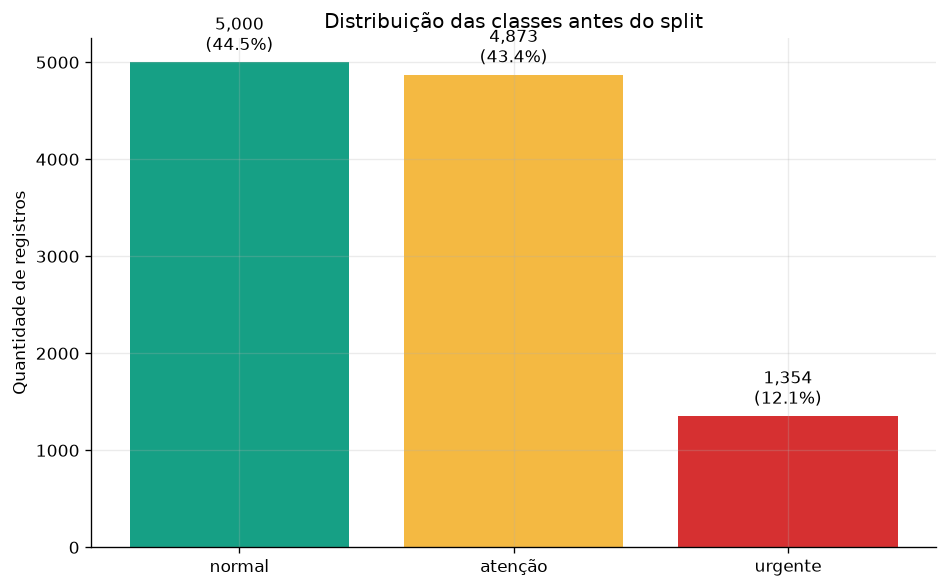

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    class_distribution["classe"],
    class_distribution["quantidade"],
    color=[COLORS[label] for label in class_distribution["classe"]],
)

ax.bar_label(
    bars,
    labels=[
        f"{count:,}\n({pct:.1%})"
        for count, pct in zip(
            class_distribution["quantidade"],
            class_distribution["percentual"],
        )
    ],
    padding=4,
)

ax.set_title("Distribuição das classes antes do split")
ax.set_ylabel("Quantidade de registros")

plt.tight_layout()
plt.show()

## 6. Divisão estratificada

Primeiro separamos 70% para treino.  
Depois dividimos os 30% restantes igualmente entre validação e teste.

In [7]:
train_df, temp_df = train_test_split(
    model_data,
    test_size=(VALIDATION_SIZE + TEST_SIZE),
    random_state=RANDOM_STATE,
    stratify=model_data["triage_level"],
)

relative_test_size = TEST_SIZE / (VALIDATION_SIZE + TEST_SIZE)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    random_state=RANDOM_STATE,
    stratify=temp_df["triage_level"],
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Treino:    {len(train_df):,}")
print(f"Validação: {len(validation_df):,}")
print(f"Teste:     {len(test_df):,}")
print(f"Total:     {len(train_df) + len(validation_df) + len(test_df):,}")

Treino:    7,858
Validação: 1,684
Teste:     1,685
Total:     11,227


## 7. Distribuição por conjunto

In [8]:
def split_distribution(dataframe, split_name):
    result = (
        dataframe["triage_level"]
        .value_counts()
        .reindex(CLASS_ORDER, fill_value=0)
        .rename_axis("classe")
        .reset_index(name="quantidade")
    )

    result["percentual"] = result["quantidade"] / len(dataframe)
    result["conjunto"] = split_name
    return result


distribution_by_split = pd.concat([
    split_distribution(train_df, "Treino"),
    split_distribution(validation_df, "Validação"),
    split_distribution(test_df, "Teste"),
], ignore_index=True)

display(distribution_by_split)

,classe,quantidade,percentual,conjunto
0,normal,3499,0.4453,Treino
1,atenção,3411,0.4341,Treino
2,urgente,948,0.1206,Treino
3,normal,750,0.4454,Validação
4,atenção,731,0.4341,Validação
5,urgente,203,0.1205,Validação
6,normal,751,0.4457,Teste
7,atenção,731,0.4338,Teste
8,urgente,203,0.1205,Teste


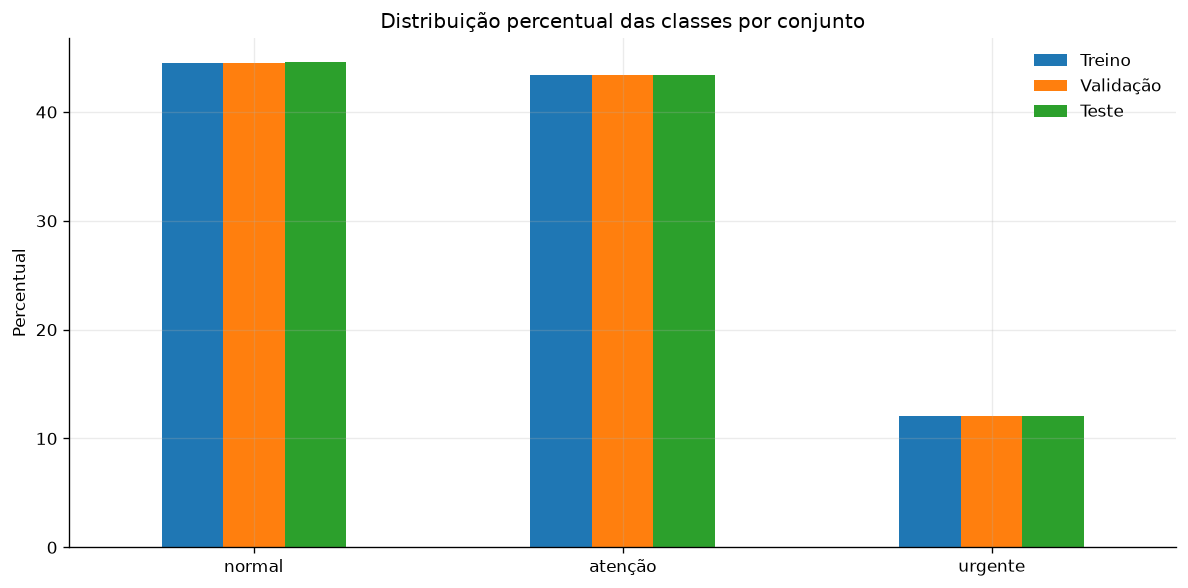

In [9]:
comparison = (
    distribution_by_split
    .pivot(index="classe", columns="conjunto", values="percentual")
    .reindex(CLASS_ORDER)
)

ax = (
    comparison[["Treino", "Validação", "Teste"]]
    .mul(100)
    .plot(kind="bar", figsize=(10, 5))
)

ax.set_title("Distribuição percentual das classes por conjunto")
ax.set_xlabel("")
ax.set_ylabel("Percentual")
ax.legend(frameon=False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Verificação de vazamento

In [10]:
train_texts = set(train_df["medical_abstract"])
validation_texts = set(validation_df["medical_abstract"])
test_texts = set(test_df["medical_abstract"])

leakage_check = pd.DataFrame({
    "comparação": [
        "Treino x Validação",
        "Treino x Teste",
        "Validação x Teste",
    ],
    "textos_em_comum": [
        len(train_texts & validation_texts),
        len(train_texts & test_texts),
        len(validation_texts & test_texts),
    ],
})

display(leakage_check)

assert (leakage_check["textos_em_comum"] == 0).all()

print("Nenhum vazamento de texto encontrado.")

,comparação,textos_em_comum
0,Treino x Validação,0
1,Treino x Teste,0
2,Validação x Teste,0


Nenhum vazamento de texto encontrado.


## 9. Quantidade de exemplos por classe

Esta tabela é especialmente útil para conferir quantos exemplos da classe `urgente` ficaram em cada conjunto.

In [11]:
split_counts = (
    distribution_by_split
    .pivot(index="classe", columns="conjunto", values="quantidade")
    .reindex(CLASS_ORDER)
    .fillna(0)
    .astype(int)
)

display(split_counts)

conjunto,Teste,Treino,Validação
classe,,,
normal,751,3499,750
atenção,731,3411,731
urgente,203,948,203


## 10. Embaralhamento final

In [12]:
train_df = train_df.sample(
    frac=1,
    random_state=RANDOM_STATE,
).reset_index(drop=True)

validation_df = validation_df.sample(
    frac=1,
    random_state=RANDOM_STATE,
).reset_index(drop=True)

test_df = test_df.sample(
    frac=1,
    random_state=RANDOM_STATE,
).reset_index(drop=True)

## 11. Salvamento dos conjuntos

In [13]:
TRAIN_OUTPUT = SPLITS_DIR / "train.csv"
VALIDATION_OUTPUT = SPLITS_DIR / "validation.csv"
TEST_OUTPUT = SPLITS_DIR / "test.csv"

train_df.to_csv(TRAIN_OUTPUT, index=False)
validation_df.to_csv(VALIDATION_OUTPUT, index=False)
test_df.to_csv(TEST_OUTPUT, index=False)

print(f"Treino:    {TRAIN_OUTPUT}")
print(f"Validação: {VALIDATION_OUTPUT}")
print(f"Teste:     {TEST_OUTPUT}")

Treino:    C:\Users\erick\projetos\medical-triage-mlops\data\processed\splits\train.csv
Validação: C:\Users\erick\projetos\medical-triage-mlops\data\processed\splits\validation.csv
Teste:     C:\Users\erick\projetos\medical-triage-mlops\data\processed\splits\test.csv


## 12. Variáveis para o próximo notebook

O MLP utilizará somente:

```text
X = medical_abstract
y = triage_level
```

Não usaremos `urgent_score`, `nonurgent_score` ou `confidence` como entrada.

In [14]:
X_train = train_df["medical_abstract"]
y_train = train_df["triage_level"]

X_validation = validation_df["medical_abstract"]
y_validation = validation_df["triage_level"]

X_test = test_df["medical_abstract"]
y_test = test_df["triage_level"]

print("Shapes:")
print(f"Treino:    {X_train.shape}")
print(f"Validação: {X_validation.shape}")
print(f"Teste:     {X_test.shape}")

Shapes:
Treino:    (7858,)
Validação: (1684,)
Teste:     (1685,)


## 13. Conclusão

Os dados ficam salvos em:

```text
data/processed/splits/
├── train.csv
├── validation.csv
└── test.csv
```

### Próximo notebook

```text
06_mlp_training.ipynb
```

Fluxo:

```text
medical_abstract
      ↓
TF-IDF
      ↓
MLPClassifier
      ↓
normal / atenção / urgente
```

As principais métricas serão:

- accuracy;
- macro F1-score;
- precision e recall por classe;
- matriz de confusão;
- latência de inferência.